# 2D Unfolding Notebook — Z+jet Jet Mass

Performs 2D (pT × mass) unfolding using **TUnfoldDensity** with inputs loaded from
per-year pickle files containing `hist` objects.

**Axis convention (response matrix)**  
- X axis (columns) → generator level (ptgen, mgen) — global gen bins  
- Y axis (rows)    → reco level     (ptreco, mreco) — global reco bins  
- This matches TUnfoldDensity's internal convention: `A[reco, gen]`

**Global bin ordering**  
Bins are flattened *mass-fast within each pT block*:  
`global_bin = pt_idx * n_mass_bins + mass_idx`

**Fakes / Misses**  
- **Misses** (efficiency): gen events not reconstructed → derived from  
  `ptjet_mjet_*_gen` minus the gen-axis projection of the response matrix  
- **Fakes**: reco events with no gen match → derived from  
  `ptjet_mjet_*_reco` (MC) minus the reco-axis projection of the response matrix  
- Data input is already background-subtracted; fakes are passed to TUnfold as background

**No regularisation** — consistent with the Z+jet AN finding (τ = 0)

## 0  — Configuration  ← edit here

In [1]:
# ── Observable flag ──────────────────────────────────────────────────────────
# 'u' → ungroomed jet mass
# 'g' → groomed (soft-drop) jet mass
OBS = 'u'

# ── Two-MC comparison flag ───────────────────────────────────────────────────
# Set True to unfold data with BOTH Pythia (main) and Herwig (alt) response
# matrices, then overlay the two unfolded results in every mass plot.
USE_TWO_MC = True

# ── Pickle file paths (one per year) ────────────────────────────────────────
# MC files contain: response_matrix_{u/g}, ptjet_mjet_{u/g}_{reco/gen}
# Data files contain: ptjet_mjet_{u/g}_reco  (background-subtracted)
MC_FILES = {
    '2016'   : 'inputs/massInputs/fine_bin/mass_pythia_2016.pkl',
    # '2016APV': 'inputs/massInputs/fine_bin/mass_pythia_2016APV.pkl',
    '2017'   : 'inputs/massInputs/fine_bin/mass_pythia_2017.pkl',
    '2018'   : 'inputs/massInputs/fine_bin/mass_pythia_2018.pkl',
}
DATA_FILES = {
    '2016'   : 'inputs/massInputs/fine_bin/mass_data_2016.pkl',
    # '2016APV': 'inputs/massInputs/fine_bin/mass_data_2016APV.pkl',
    '2017'   : 'inputs/massInputs/fine_bin/mass_data_2017.pkl',
    '2018'   : 'inputs/massInputs/fine_bin/mass_data_2018.pkl',
}

# ── Alt MC (Herwig) — only used when USE_TWO_MC = True ──────────────────────
MC_FILES_ALT = {
    '2016'   : 'inputs/massInputs/fine_bin/mass_herwig_2016.pkl',
    # '2016APV': 'inputs/massInputs/fine_bin/mass_herwig_2016APV.pkl',
    '2017'   : 'inputs/massInputs/fine_bin/mass_herwig_2017.pkl',
    '2018'   : 'inputs/massInputs/fine_bin/mass_herwig_2018.pkl',
}

# ── Regularisation ───────────────────────────────────────────────────────────
# Set to 0 for no regularisation (Z+jet default).
# Uncomment the L-curve block further below to scan if needed.
TAU = 0.0

print(f'Observable : {"ungroomed" if OBS=="u" else "groomed"} jet mass')
print(f'Regularisation τ = {TAU}')
print(f'Two-MC mode      : {"ON  (Pythia + Herwig)" if USE_TWO_MC else "OFF (Pythia only)"}')

Observable : ungroomed jet mass
Regularisation τ = 0.0
Two-MC mode      : ON  (Pythia + Herwig)


## 1  — Imports

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import mplhep as hep

hep.style.use('CMS')

import ROOT
ROOT.gROOT.SetBatch(True)   # never open a TCanvas window
ROOT.TH1.SetDefaultSumw2()  # always propagate Poisson weights

print('ROOT version :', ROOT.__version__)
print('numpy version:', np.__version__)


ROOT version : 6.38.04
numpy version: 2.4.3


## 2  — Load and sum histograms across years

In [3]:
def load_pkl(path: str) -> dict:
    """Load a pickle file and return the contents dict."""
    with open(path, 'rb') as f:
        return pickle.load(f)


def sum_hist_over_years(files: dict, key: str, project_axes: tuple[str, ...] | None = None):
    """
    Load `key` from each year pkl, optionally project away non-physics axes,
    and return the sum of the projected histograms.
    """
    total = None
    for year, path in files.items():
        out = load_pkl(path)
        h = out[key]
        if project_axes is not None:
            h = h.project(*project_axes)
        total = h if total is None else total + h
        print(f"  loaded {key} from {year} with axes {[ax.name for ax in h.axes]}")
    return total


print('=== Loading MC histograms (Pythia) ===')
response_hist = sum_hist_over_years(
    MC_FILES,
    f'response_matrix_{OBS}',
    ('ptreco', 'mreco', 'ptgen', 'mgen'),
)
mc_reco_hist = sum_hist_over_years(
    MC_FILES,
    f'ptjet_mjet_{OBS}_reco',
    ('ptreco', 'mreco'),
)
mc_gen_hist = sum_hist_over_years(
    MC_FILES,
    f'ptjet_mjet_{OBS}_gen',
    ('ptgen', 'mgen'),
)

print('\n=== Loading Data histograms ===')
data_reco_hist = sum_hist_over_years(
    DATA_FILES,
    f'ptjet_mjet_{OBS}_reco',
    ('ptreco', 'mreco'),
)

if USE_TWO_MC:
    print('\n=== Loading MC histograms (Herwig — alt) ===')
    response_hist_alt = sum_hist_over_years(
        MC_FILES_ALT,
        f'response_matrix_{OBS}',
        ('ptreco', 'mreco', 'ptgen', 'mgen'),
    )
    mc_reco_hist_alt = sum_hist_over_years(
        MC_FILES_ALT,
        f'ptjet_mjet_{OBS}_reco',
        ('ptreco', 'mreco'),
    )
    mc_gen_hist_alt = sum_hist_over_years(
        MC_FILES_ALT,
        f'ptjet_mjet_{OBS}_gen',
        ('ptgen', 'mgen'),
    )

=== Loading MC histograms (Pythia) ===
  loaded response_matrix_u from 2016 with axes ['ptreco', 'mreco', 'ptgen', 'mgen']
  loaded response_matrix_u from 2017 with axes ['ptreco', 'mreco', 'ptgen', 'mgen']
  loaded response_matrix_u from 2018 with axes ['ptreco', 'mreco', 'ptgen', 'mgen']
  loaded ptjet_mjet_u_reco from 2016 with axes ['ptreco', 'mreco']
  loaded ptjet_mjet_u_reco from 2017 with axes ['ptreco', 'mreco']
  loaded ptjet_mjet_u_reco from 2018 with axes ['ptreco', 'mreco']
  loaded ptjet_mjet_u_gen from 2016 with axes ['ptgen', 'mgen']
  loaded ptjet_mjet_u_gen from 2017 with axes ['ptgen', 'mgen']
  loaded ptjet_mjet_u_gen from 2018 with axes ['ptgen', 'mgen']

=== Loading Data histograms ===
  loaded ptjet_mjet_u_reco from 2016 with axes ['ptreco', 'mreco']
  loaded ptjet_mjet_u_reco from 2017 with axes ['ptreco', 'mreco']
  loaded ptjet_mjet_u_reco from 2018 with axes ['ptreco', 'mreco']

=== Loading MC histograms (Herwig — alt) ===
  loaded response_matrix_u from 2016

## 3  — Extract numpy arrays and bin edges from hist objects

In [4]:
# ── Response matrix ──────────────────────────────────────────────────────────
# Project to the four axes we need in the order: (ptgen, mgen, ptreco, mreco)
# Then we get shape  (n_ptgen, n_mgen, n_ptreco, n_mreco)
# Transpose to (n_ptreco, n_mreco, n_ptgen, n_mgen) so that after flattening
# we obtain a 2D matrix with shape  (n_reco_global, n_gen_global)  ← A[reco,gen]

resp_proj = response_hist.project('ptgen', 'mgen', 'ptreco', 'mreco')

# Bin edges  (we derive them from the hist axes)
ptgen_edges  = np.array(resp_proj.axes['ptgen'].edges)
mgen_edges   = np.array(resp_proj.axes['mgen'].edges)
ptreco_edges = np.array(resp_proj.axes['ptreco'].edges)
mreco_edges  = np.array(resp_proj.axes['mreco'].edges)

n_ptgen  = len(ptgen_edges)  - 1
n_mgen   = len(mgen_edges)   - 1
n_ptreco = len(ptreco_edges) - 1
n_mreco  = len(mreco_edges)  - 1

n_gen_global  = n_ptgen  * n_mgen
n_reco_global = n_ptreco * n_mreco

print(f'Gen  bins : {n_ptgen} pT × {n_mgen} mass  = {n_gen_global} global')
print(f'Reco bins : {n_ptreco} pT × {n_mreco} mass = {n_reco_global} global')

# values() shape: (n_ptgen, n_mgen, n_ptreco, n_mreco)
resp_4d = np.asarray(resp_proj.values())          # (ptgen, mgen, ptreco, mreco)
resp_4d = resp_4d.transpose(2, 3, 0, 1)           # → (ptreco, mreco, ptgen, mgen)

# Flatten: mass-fast within each pT block
# shape → (n_reco_global, n_gen_global)  i.e. A[reco_global, gen_global]
response_2d = resp_4d.reshape(n_reco_global, n_gen_global)

print(f'Response matrix shape: {response_2d.shape}  (reco_global × gen_global)')

# ── Alt (Herwig) response matrix ─────────────────────────────────────────────
if USE_TWO_MC:
    resp_proj_alt  = response_hist_alt.project('ptgen', 'mgen', 'ptreco', 'mreco')
    resp_4d_alt    = np.asarray(resp_proj_alt.values()).transpose(2, 3, 0, 1)
    response_2d_alt = resp_4d_alt.reshape(n_reco_global, n_gen_global)
    print(f'Alt (Herwig) response matrix shape: {response_2d_alt.shape}')

Gen  bins : 4 pT × 106 mass  = 424 global
Reco bins : 4 pT × 213 mass = 852 global
Response matrix shape: (852, 424)  (reco_global × gen_global)
Alt (Herwig) response matrix shape: (852, 424)


In [7]:
# ── Reco-level distributions ─────────────────────────────────────────────────
# Both MC and data: project to (ptreco, mreco), then flatten mass-fast

def flatten_reco_hist(h):
    """Project (ptreco, mreco) hist to a flat 1D numpy array."""
    arr = np.asarray(h.project('ptreco', 'mreco').values())  # (n_ptreco, n_mreco)
    return arr.flatten()   # mass-fast: arr[ipt * n_mreco + im]

def flatten_gen_hist(h):
    """Project (ptgen, mgen) hist to a flat 1D numpy array."""
    arr = np.asarray(h.project('ptgen', 'mgen').values())    # (n_ptgen, n_mgen)
    return arr.flatten()


data_reco_flat = flatten_reco_hist(data_reco_hist)   # y  (input to TUnfold)
mc_reco_flat   = flatten_reco_hist(mc_reco_hist)
mc_gen_flat    = flatten_gen_hist(mc_gen_hist)

# ── Fakes and Misses ─────────────────────────────────────────────────────────
# response_2d.sum(axis=1)  → for each reco bin: total MC events matched to any gen bin
# response_2d.sum(axis=0)  → for each gen  bin: total MC events matched to any reco bin

reco_matched = response_2d.sum(axis=1)   # shape (n_reco_global,)
gen_matched  = response_2d.sum(axis=0)   # shape (n_gen_global,)

# Fakes: MC reco events with no gen-level match
fakes_flat = np.maximum(mc_reco_flat - reco_matched, 0.0)

# Misses: gen events that were not reconstructed  → used to build efficiency
misses_flat = np.maximum(mc_gen_flat - gen_matched, 0.0)

# Efficiency per gen bin
with np.errstate(divide='ignore', invalid='ignore'):
    efficiency_flat = np.where(
        mc_gen_flat > 0,
        gen_matched / mc_gen_flat,
        0.0
    )

print(f'Total fakes  : {fakes_flat.sum():.1f}')
print(f'Total misses : {misses_flat.sum():.1f}')
print(f'Mean efficiency: {efficiency_flat[efficiency_flat>0].mean():.3f}')

# ── Alt (Herwig) fakes / misses ───────────────────────────────────────────────
if USE_TWO_MC:
    mc_reco_flat_alt = flatten_reco_hist(mc_reco_hist_alt)
    mc_gen_flat_alt  = flatten_gen_hist(mc_gen_hist_alt)

    reco_matched_alt = response_2d_alt.sum(axis=1)
    gen_matched_alt  = response_2d_alt.sum(axis=0)

    fakes_flat_alt  = np.maximum(mc_reco_flat_alt - reco_matched_alt, 0.0)
    misses_flat_alt = np.maximum(mc_gen_flat_alt  - gen_matched_alt,  0.0)
    with np.errstate(divide='ignore', invalid='ignore'):
        efficiency_flat_alt = np.where(mc_gen_flat_alt > 0,
                                       gen_matched_alt / mc_gen_flat_alt, 0.0)
    print(f'\nAlt total fakes  : {fakes_flat_alt.sum():.1f}')
    print(f'Alt total misses : {misses_flat_alt.sum():.1f}')
    print(f'Alt mean efficiency: {efficiency_flat_alt[efficiency_flat_alt>0].mean():.3f}')

Total fakes  : 6180.7
Total misses : 133839.8
Mean efficiency: 0.667

Alt total fakes  : 9.9
Alt total misses : 235.8
Alt mean efficiency: 0.668


## 4  — Build ROOT TH2 for the response matrix and TH1s for inputs

In [8]:

def make_th1(name: str, values: np.ndarray, title: str = '') -> ROOT.TH1D:
    """
    Create a TH1D from a flat numpy array.
    Bins are numbered 1..N (uniform spacing — TUnfold only needs counts).
    """
    n = len(values)
    h = ROOT.TH1D(name, title, n, 0.5, n + 0.5)
    for i, v in enumerate(values, start=1):
        h.SetBinContent(i, v)
        h.SetBinError(i, np.sqrt(max(v, 0.0)))
    return h


def make_th2_response(name: str, matrix: np.ndarray,
                      fakes: np.ndarray, title: str = '') -> ROOT.TH2D:
    """
    Create a TH2D response matrix from a 2D numpy array.
    matrix shape: (n_reco_global, n_gen_global)
    TUnfoldDensity convention: X axis = gen (measured), Y axis = reco (folded)
    i.e. TH2[gen_bin, reco_bin]  →  we fill it as matrix.T
    fakes: 1D array of length n_reco_global for the underflow (fake) column.
    """
    n_reco, n_gen = matrix.shape
    # +1 in gen axis for the underflow bin (TUnfold uses bin 0 for fakes by convention)
    h = ROOT.TH2D(name, title,
                  n_gen + 1, -0.5, n_gen + 0.5,   # X = gen  (bin 0 = fake col)
                  n_reco,    0.5,  n_reco + 0.5)   # Y = reco
    for ireco in range(n_reco):
        for igen in range(n_gen):
            # TH2 bin indices are 1-based; gen axis shifted by +1 (bin 0 = fakes)
            h.SetBinContent(igen + 2, ireco + 1, matrix[ireco, igen])
    # Fill the fakes column (gen underflow, bin 0 in X → TH2 X-bin 1)
    for ireco in range(n_reco):
        h.SetBinContent(1, ireco + 1, fakes[ireco])
    return h


def make_tunfold_binning(name: str, pt_edges: np.ndarray, m_edges: np.ndarray) -> ROOT.TUnfoldBinning:
    """
    Build a TUnfoldBinning for the 2D (pT × mass) space.

    Each pT slice becomes a separate sub-node with a mass axis that carries
    the actual (possibly non-uniform) bin edges.  This has two effects on the
    regularisation L-matrix built by TUnfoldDensity:
      1. Derivative/curvature penalties are computed with the correct physical
         mass bin widths, not with the uniform unit spacing that the flat TH1
         would imply.
      2. Bins from *different* pT nodes are never connected by the L-matrix,
         so no spurious cross-pT regularisation is introduced.

    The sub-node ordering (pT0[m0..mN], pT1[m0..mN], …) matches the
    global-bin convention used in the TH2/TH1 histograms
    (global = pt_idx * n_mass + mass_idx), so no bin re-mapping is needed.
    """
    n_pt        = len(pt_edges) - 1
    m_edges_arr = np.asarray(m_edges, dtype=np.float64)
    n_m         = len(m_edges_arr) - 1
    binning     = ROOT.TUnfoldBinning(name)
    for ipt in range(n_pt):
        node = binning.AddBinning(f"{name}_pt{ipt}")
        node.AddAxis("m", n_m, m_edges_arr, False, False)
    return binning


h_response = make_th2_response(f'h_response_{OBS}', response_2d, fakes_flat,
                                'Response matrix;gen global bin;reco global bin')

h_data     = make_th1(f'h_data_{OBS}',   data_reco_flat, 'Data (bkg-subtracted);reco global bin;counts')
h_mc_reco  = make_th1(f'h_mc_reco_{OBS}',  mc_reco_flat, 'MC reco;reco global bin;counts')
h_mc_gen   = make_th1(f'h_mc_gen_{OBS}',   mc_gen_flat,  'MC gen;gen global bin;counts')

# ── TUnfoldBinning objects — encode pT×mass structure for the L-matrix ───────
# Providing these to TUnfoldDensity ensures the regularisation uses the real
# mass bin widths and does not connect bins across pT-block boundaries.
gen_binning  = make_tunfold_binning('gen',  ptgen_edges,  mgen_edges)
reco_binning = make_tunfold_binning('reco', ptreco_edges, mreco_edges)

print('TH2 response :', h_response.GetNbinsX(), '(gen+1) ×', h_response.GetNbinsY(), '(reco)')
print('TH1 data entries :', h_data.GetEntries())
print(f'gen_binning  total bins : {gen_binning.GetDistributionNumberOfBins()}  (should == {n_gen_global})')
print(f'reco_binning total bins : {reco_binning.GetDistributionNumberOfBins()}  (should == {n_reco_global})')

if USE_TWO_MC:
    h_response_alt = make_th2_response(
        f'h_response_alt_{OBS}', response_2d_alt, fakes_flat_alt,
        'Response matrix (Herwig);gen global bin;reco global bin'
    )
    h_mc_reco_alt = make_th1(f'h_mc_reco_alt_{OBS}', mc_reco_flat_alt, 'MC reco (Herwig)')
    h_mc_gen_alt  = make_th1(f'h_mc_gen_alt_{OBS}',  mc_gen_flat_alt,  'MC gen (Herwig)')
    print('Alt TH2 response :', h_response_alt.GetNbinsX(), '(gen+1) ×', h_response_alt.GetNbinsY(), '(reco)')


TH2 response : 425 (gen+1) × 852 (reco)
TH1 data entries : 852.0
gen_binning  total bins : 0  (should == 424)
reco_binning total bins : 0  (should == 852)
Alt TH2 response : 425 (gen+1) × 852 (reco)


Warning in <TROOT::Append>: Replacing existing TH1: h_response_u (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_data_u (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_mc_reco_u (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_mc_gen_u (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_response_alt_u (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_mc_reco_alt_u (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_mc_gen_alt_u (Potential memory leak).


In [28]:

# ── Sanity check: numpy response_2d  ↔  ROOT TH2 bin contents ───────────────
# Sample near-diagonal entries (±5 off-diagonal) where the matrix is non-zero
rng = np.random.default_rng(seed=42)

print('Near-diagonal spot-checks (numpy vs ROOT, offset ∈ [-5, +5]):')
print('=' * 75)
all_ok = True
n_checks = 12

checked = 0
attempts = 0
while checked < n_checks and attempts < 10000:
    attempts += 1
    ig   = int(rng.integers(0, n_gen_global))
    doff = int(rng.integers(-5, 6))          # offset from diagonal: -5 … +5
    ir   = ig + doff
    if ir < 0 or ir >= n_reco_global:
        continue

    nv = response_2d[ir, ig]
    rv = h_response.GetBinContent(ig + 2, ir + 1)
    ok = np.isclose(nv, rv, rtol=1e-9)
    all_ok = all_ok and ok

    # Decode back to (ipt, im) for readability
    ipt_gen  = ig // n_mgen;  im_gen  = ig % n_mgen
    ipt_reco = ir // n_mreco; im_reco = ir % n_mreco
    flag = "✓" if ok else "✗ MISMATCH"
    print(f'  gen(pt={ipt_gen},m={im_gen:2d}) reco(pt={ipt_reco},m={im_reco:2d})'
          f'  [ig={ig:3d} ir={ir:3d} Δ={doff:+d}]'
          f'  np={nv:10.3f}  ROOT={rv:10.3f}  {flag}')
    checked += 1

print('-' * 75)
print(f'All {checked} checks passed: {all_ok}')


Near-diagonal spot-checks (numpy vs ROOT, offset ∈ [-5, +5]):
  gen(pt=0,m=37) reco(pt=0,m=40)  [ig= 37 ir= 40 Δ=+3]  np=     0.122  ROOT=     0.122  ✓
  gen(pt=2,m=65) reco(pt=1,m=63)  [ig=277 ir=276 Δ=-1]  np=     0.000  ROOT=     0.000  ✓
  gen(pt=1,m=77) reco(pt=0,m=187)  [ig=183 ir=187 Δ=+4]  np=     0.000  ROOT=     0.000  ✓
  gen(pt=0,m=36) reco(pt=0,m=38)  [ig= 36 ir= 38 Δ=+2]  np=     0.241  ROOT=     0.241  ✓
  gen(pt=0,m=85) reco(pt=0,m=81)  [ig= 85 ir= 81 Δ=-4]  np=     0.000  ROOT=     0.000  ✓
  gen(pt=2,m=11) reco(pt=1,m=15)  [ig=223 ir=228 Δ=+5]  np=     0.000  ROOT=     0.000  ✓
  gen(pt=2,m=99) reco(pt=1,m=101)  [ig=311 ir=314 Δ=+3]  np=     0.000  ROOT=     0.000  ✓
  gen(pt=2,m=92) reco(pt=1,m=94)  [ig=304 ir=307 Δ=+3]  np=     0.000  ROOT=     0.000  ✓
  gen(pt=2,m= 5) reco(pt=1,m= 0)  [ig=217 ir=213 Δ=-4]  np=     0.000  ROOT=     0.000  ✓
  gen(pt=3,m=38) reco(pt=1,m=142)  [ig=356 ir=355 Δ=-1]  np=     0.000  ROOT=     0.000  ✓
  gen(pt=2,m= 0) reco(pt=0,m=211)  

## 5  — Configure and run TUnfoldDensity

In [ ]:

tunfold = ROOT.TUnfoldDensity(
    h_response,
    ROOT.TUnfold.kHistMapOutputHoriz,   # gen on X axis
    ROOT.TUnfold.kRegModeDerivative,    # derivative regularisation
    ROOT.TUnfold.kEConstraintArea,      # area constraint
    ROOT.TUnfoldDensity.kDensityModeBinWidth,
    gen_binning,                        # gen  binning → correct mass widths + no cross-pT reg.
    reco_binning,                       # reco binning
)
tunfold.SetInput(h_data)

# ── τ selection ─────────────────────────────────────────────────────────────────────────────
if TAU == 0:
    logTau_min, logTau_max, n_steps = -6, -1, 50
    h_lcurve = ROOT.TGraph()
    # ScanLcurve expects actual tau values (not log10); pass 10**logTau_min/max
    iBest = tunfold.ScanLcurve(n_steps, 10**logTau_min, 10**logTau_max, h_lcurve)
    t_best = tunfold.GetTau()
    # DoUnfold after ScanLcurve is a no-op but returns the status code
    status = tunfold.DoUnfold(t_best)
    print(f"L-curve scan: {n_steps} points, log10(τ) ∈ [{logTau_min}, {logTau_max}]")
    print(f"L-curve best τ = {t_best:.4e}  (scan index {iBest})")
else:
    t_best = TAU
    status = tunfold.DoUnfold(t_best)

print(f"TUnfold status: {status}  (0 = OK, >0 = warnings/errors)")
h_unfolded_root = tunfold.GetOutput(f"h_unfolded_{OBS}")
print(f"Unfolded bins: {h_unfolded_root.GetNbinsX()}")

# ── Alt (Herwig) unfolding — uses same τ as nominal ────────────────────────────────────────────
if USE_TWO_MC:
    tunfold_alt = ROOT.TUnfoldDensity(
        h_response_alt,
        ROOT.TUnfold.kHistMapOutputHoriz,
        ROOT.TUnfold.kRegModeDerivative,
        ROOT.TUnfold.kEConstraintArea,
        ROOT.TUnfoldDensity.kDensityModeBinWidth,
        gen_binning,
        reco_binning,
    )
    tunfold_alt.SetInput(h_data)
    status_alt = tunfold_alt.DoUnfold(t_best)
    h_unfolded_root_alt = tunfold_alt.GetOutput(f"h_unfolded_alt_{OBS}")
    print(f"Alt (Herwig) TUnfold status: {status_alt}  (0 = OK, >0 = warnings/errors)")


## 6  — Extract unfolded result + covariance into numpy

In [10]:
def th1_to_numpy(h: ROOT.TH1) -> tuple[np.ndarray, np.ndarray]:
    """Return (values, errors) arrays from a TH1, excluding under/overflow."""
    n = h.GetNbinsX()
    vals = np.array([h.GetBinContent(i) for i in range(1, n + 1)])
    errs = np.array([h.GetBinError(i)   for i in range(1, n + 1)])
    return vals, errs


def get_covariance(tunfold_obj, name: str) -> np.ndarray:
    """Extract the full covariance matrix from TUnfoldDensity as a numpy array."""
    h_cov = tunfold_obj.GetEmatrixTotal(name)
    n = h_cov.GetNbinsX()
    cov = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            cov[i, j] = h_cov.GetBinContent(i + 1, j + 1)
    return cov


unfolded_vals, unfolded_errs = th1_to_numpy(h_unfolded_root)
cov_matrix = get_covariance(tunfold, f'cov_{OBS}')

unfolded_vals = unfolded_vals[:n_gen_global]
unfolded_errs = unfolded_errs[:n_gen_global]
# Reshape to (n_ptgen, n_mgen) for per-pT-bin access
unfolded_2d = unfolded_vals.reshape(n_ptgen, n_mgen)
errs_2d     = unfolded_errs.reshape(n_ptgen, n_mgen)

print(f'Unfolded shape : {unfolded_2d.shape}  (n_ptgen={n_ptgen}, n_mgen={n_mgen})')
print(f'Covariance shape: {cov_matrix.shape}')

# ── Alt (Herwig) results ──────────────────────────────────────────────────────
if USE_TWO_MC:
    unfolded_vals_alt, unfolded_errs_alt = th1_to_numpy(h_unfolded_root_alt)
    cov_matrix_alt = get_covariance(tunfold_alt, f'cov_alt_{OBS}')
    unfolded_vals_alt = unfolded_vals_alt[:n_gen_global]
    unfolded_errs_alt = unfolded_errs_alt[:n_gen_global]
    unfolded_2d_alt   = unfolded_vals_alt.reshape(n_ptgen, n_mgen)
    errs_2d_alt       = unfolded_errs_alt.reshape(n_ptgen, n_mgen)
    print(f'Alt unfolded shape: {unfolded_2d_alt.shape}')

Unfolded shape : (4, 106)  (n_ptgen=4, n_mgen=106)
Covariance shape: (424, 424)
Alt unfolded shape: (4, 106)


Info in <TUnfoldBinning::CreateErrorMatrixHistogram>: Original binning can not be represented on one axis
Info in <TUnfoldBinning::CreateErrorMatrixHistogram>: Original binning can not be represented on one axis


## 7  — Diagnostic plots

### 7a  Response matrix (probability, conditioned on gen)

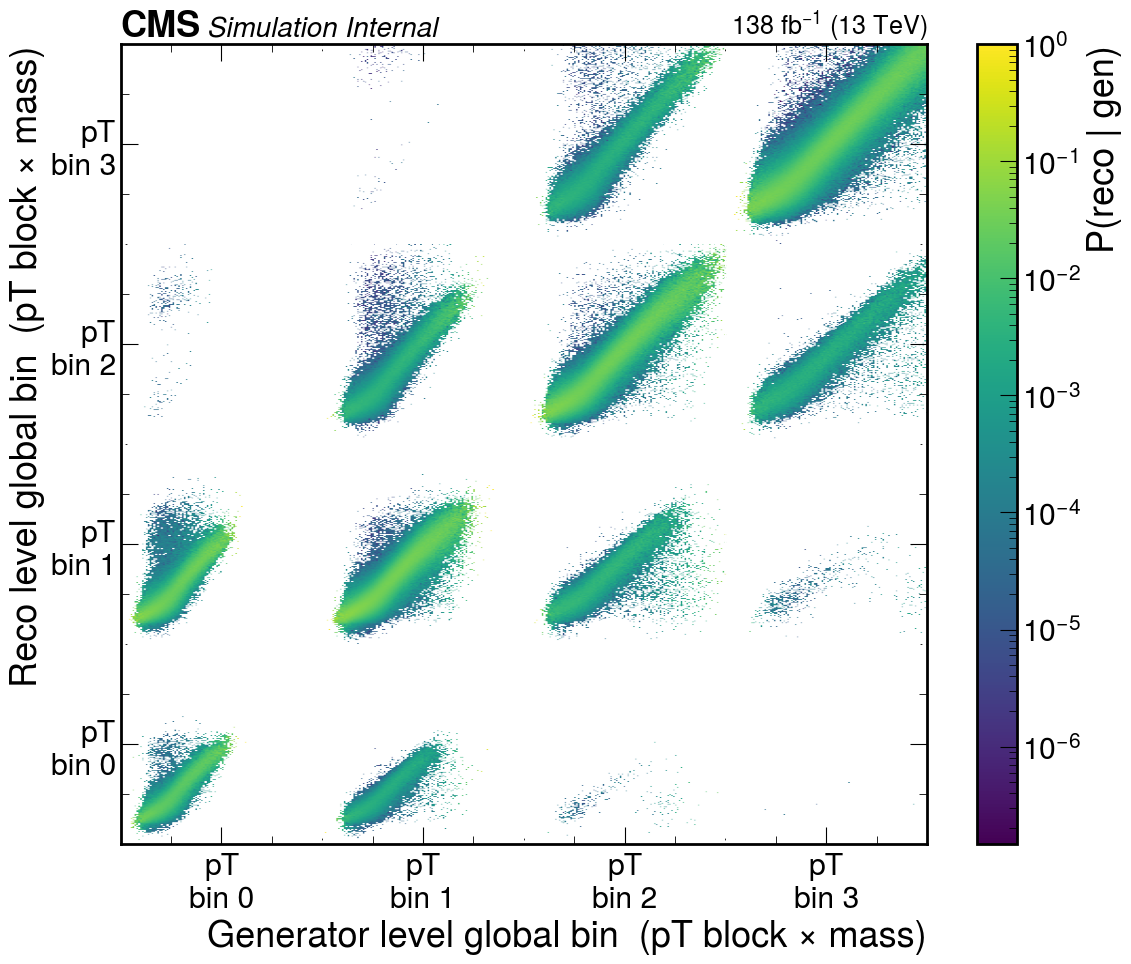

In [11]:
# Normalise columns (gen bins) to get conditional probability P(reco | gen)
col_sums = response_2d.sum(axis=0, keepdims=True)
col_sums[col_sums == 0] = 1.0
response_prob = response_2d / col_sums
# Mask zeros so they are not drawn and set masked color
response_prob = np.ma.masked_where(response_prob == 0, response_prob)
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='white', alpha=0.0)
fig, ax = plt.subplots(figsize=(12, 10))
vals = response_prob.compressed()
vmin = vals[vals > 0].min()
vmax = vals.max()
im = ax.imshow(response_prob, origin='lower', aspect='auto',
               norm=mcolors.LogNorm(vmin=vmin, vmax=vmax),
               cmap=cmap)
plt.colorbar(im, ax=ax, label='P(reco | gen)')

# Draw pT-block boundaries
for k in range(1, n_ptgen):
    ax.axvline(k * n_mgen - 0.5, color='white', lw=0.8, ls='--')
for k in range(1, n_ptreco):
    ax.axhline(k * n_mreco - 0.5, color='white', lw=0.8, ls='--')

# pT block labels on axes
pt_labels_gen  = [f'pT\nbin {i}' for i in range(n_ptgen)]
pt_labels_reco = [f'pT\nbin {i}' for i in range(n_ptreco)]
ax.set_xticks([(i + 0.5) * n_mgen  - 0.5 for i in range(n_ptgen)])
ax.set_xticklabels(pt_labels_gen)
ax.set_yticks([(i + 0.5) * n_mreco - 0.5 for i in range(n_ptreco)])
ax.set_yticklabels(pt_labels_reco)

ax.set_xlabel('Generator level global bin  (pT block × mass)')
ax.set_ylabel('Reco level global bin  (pT block × mass)')
plt.tight_layout()
hep.cms.label("Internal", lumi=138, com=13, fontsize=20, ax=ax)
plt.show()

### 7b  Purity and Stability per global bin

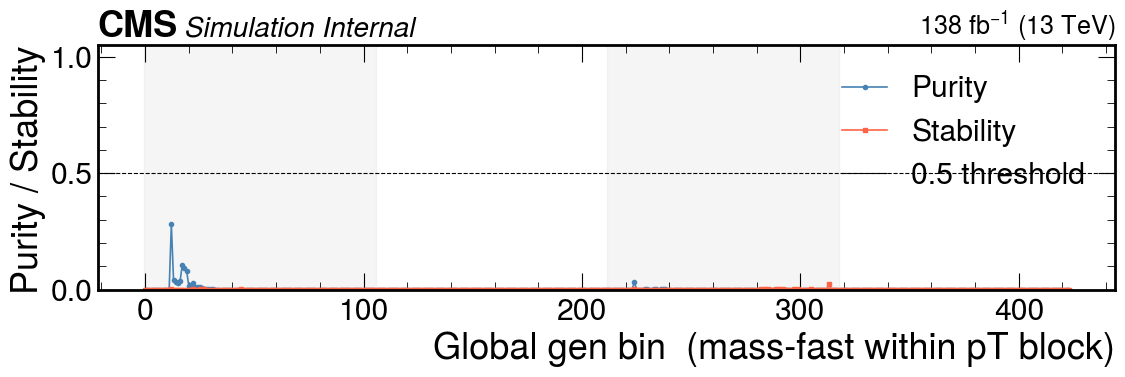

Bins below 0.5 threshold: 424 / 424


In [12]:
# Purity  P_i = M_ii / sum_j M_ji  (fraction of reco bin i that came from matched gen bin)
# Stability S_i = M_ii / sum_j M_ij  (fraction of gen bin i that ended up in matched reco bin)
# For the 2D case we compare gen and reco on a matched square submatrix

n_diag = min(n_gen_global, n_reco_global)
diag   = np.array([response_2d[i, i] for i in range(n_diag)])

col_sums_full = response_2d.sum(axis=0)   # sum over reco → denominator for stability
row_sums_full = response_2d.sum(axis=1)   # sum over gen  → denominator for purity

with np.errstate(divide='ignore', invalid='ignore'):
    purity    = np.where(row_sums_full[:n_diag] > 0, diag / row_sums_full[:n_diag], 0.0)
    stability = np.where(col_sums_full[:n_diag] > 0, diag / col_sums_full[:n_diag], 0.0)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(n_diag)
ax.plot(x, purity,    'o-', ms=3, lw=1.2, label='Purity',    color='steelblue')
ax.plot(x, stability, 's-', ms=3, lw=1.2, label='Stability', color='tomato')
ax.axhline(0.5, color='k', ls='--', lw=0.8, label='0.5 threshold')

# Shade pT block regions alternately
for k in range(n_ptgen):
    lo, hi = k * n_mgen, (k + 1) * n_mgen
    if k % 2 == 0:
        ax.axvspan(lo - 0.5, hi - 0.5, alpha=0.08, color='grey')

ax.set_xlabel('Global gen bin  (mass-fast within pT block)')
ax.set_ylabel('Purity / Stability')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
hep.cms.label("Internal", lumi=138, com=13, fontsize=20, ax=ax)
plt.show()

n_below = np.sum((purity < 0.5) | (stability < 0.5))
print(f'Bins below 0.5 threshold: {n_below} / {n_diag}')

### 7c  Unfolded mass distributions per pT bin

In [13]:
# ── Rebin configuration ──────────────────────────────────────────────────────
N_REBIN = 1   # number of adjacent mass bins to merge when CUSTOM_REBIN_EDGES is None
CUSTOM_REBIN_EDGES = [0,1, 5, 10, 20, 30, 50, 70, 90, 110, 130, 150]
# Example: CUSTOM_REBIN_EDGES = [0, 20, 30, 50, 70, 90, 110, 200]

def rebin_1d(vals, errs, edges, n=1, custom_edges=None):
    """
    Rebin a 1D histogram either by merging every `n` adjacent bins or by
    summing into explicit `custom_edges` that must coincide with existing bin edges.
    Errors are always added in quadrature.
    """
    vals = np.asarray(vals)
    errs = np.asarray(errs)
    edges = np.asarray(edges)

    if custom_edges is not None:
        edges_custom = np.asarray(custom_edges, dtype=float)
        if edges_custom.ndim != 1 or len(edges_custom) < 2:
            raise ValueError('custom_edges must be a 1D sequence with at least two entries')
        if np.any(np.diff(edges_custom) <= 0):
            raise ValueError('custom_edges must be strictly increasing')
        if edges_custom[0] < edges[0] or edges_custom[-1] > edges[-1]:
            raise ValueError('custom_edges must lie within the original bin range')

        edge_positions = []
        for edge in edges_custom:
            matches = np.where(np.isclose(edges, edge))[0]
            if len(matches) == 0:
                raise ValueError(f'Custom edge {edge} is not present in the original bin edges')
            edge_positions.append(matches[0])

        vals_r = np.array([
            vals[start:stop].sum()
            for start, stop in zip(edge_positions[:-1], edge_positions[1:])
        ])
        errs_r = np.array([
            np.sqrt(np.sum(errs[start:stop] ** 2))
            for start, stop in zip(edge_positions[:-1], edge_positions[1:])
        ])
        return vals_r, errs_r, edges_custom

    n_bins = len(vals)
    n_new = n_bins // n

    vals_r = vals[:n_new * n].reshape(n_new, n).sum(axis=1)
    errs_r = np.sqrt((errs[:n_new * n] ** 2).reshape(n_new, n).sum(axis=1))

    # Rebuild edges: take every n-th edge, plus the final right edge
    edges_r = np.append(edges[:n_new * n:n], edges[n_new * n])

    return vals_r, errs_r, edges_r

if CUSTOM_REBIN_EDGES is None:
    print(f'Using fixed rebin factor N_REBIN = {N_REBIN}')
else:
    print(f'Using custom rebin edges: {CUSTOM_REBIN_EDGES}')

Using custom rebin edges: [0, 1, 5, 10, 20, 30, 50, 70, 90, 110, 130, 150]


<>:82: SyntaxWarning: invalid escape sequence '\ '
<>:82: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_72112/3554021673.py:82: SyntaxWarning: invalid escape sequence '\ '
  title=f'$p_{{T}} \\in [{pt_lo},\ {pt_hi}]$ GeV',
/tmp/ipykernel_72112/3554021673.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


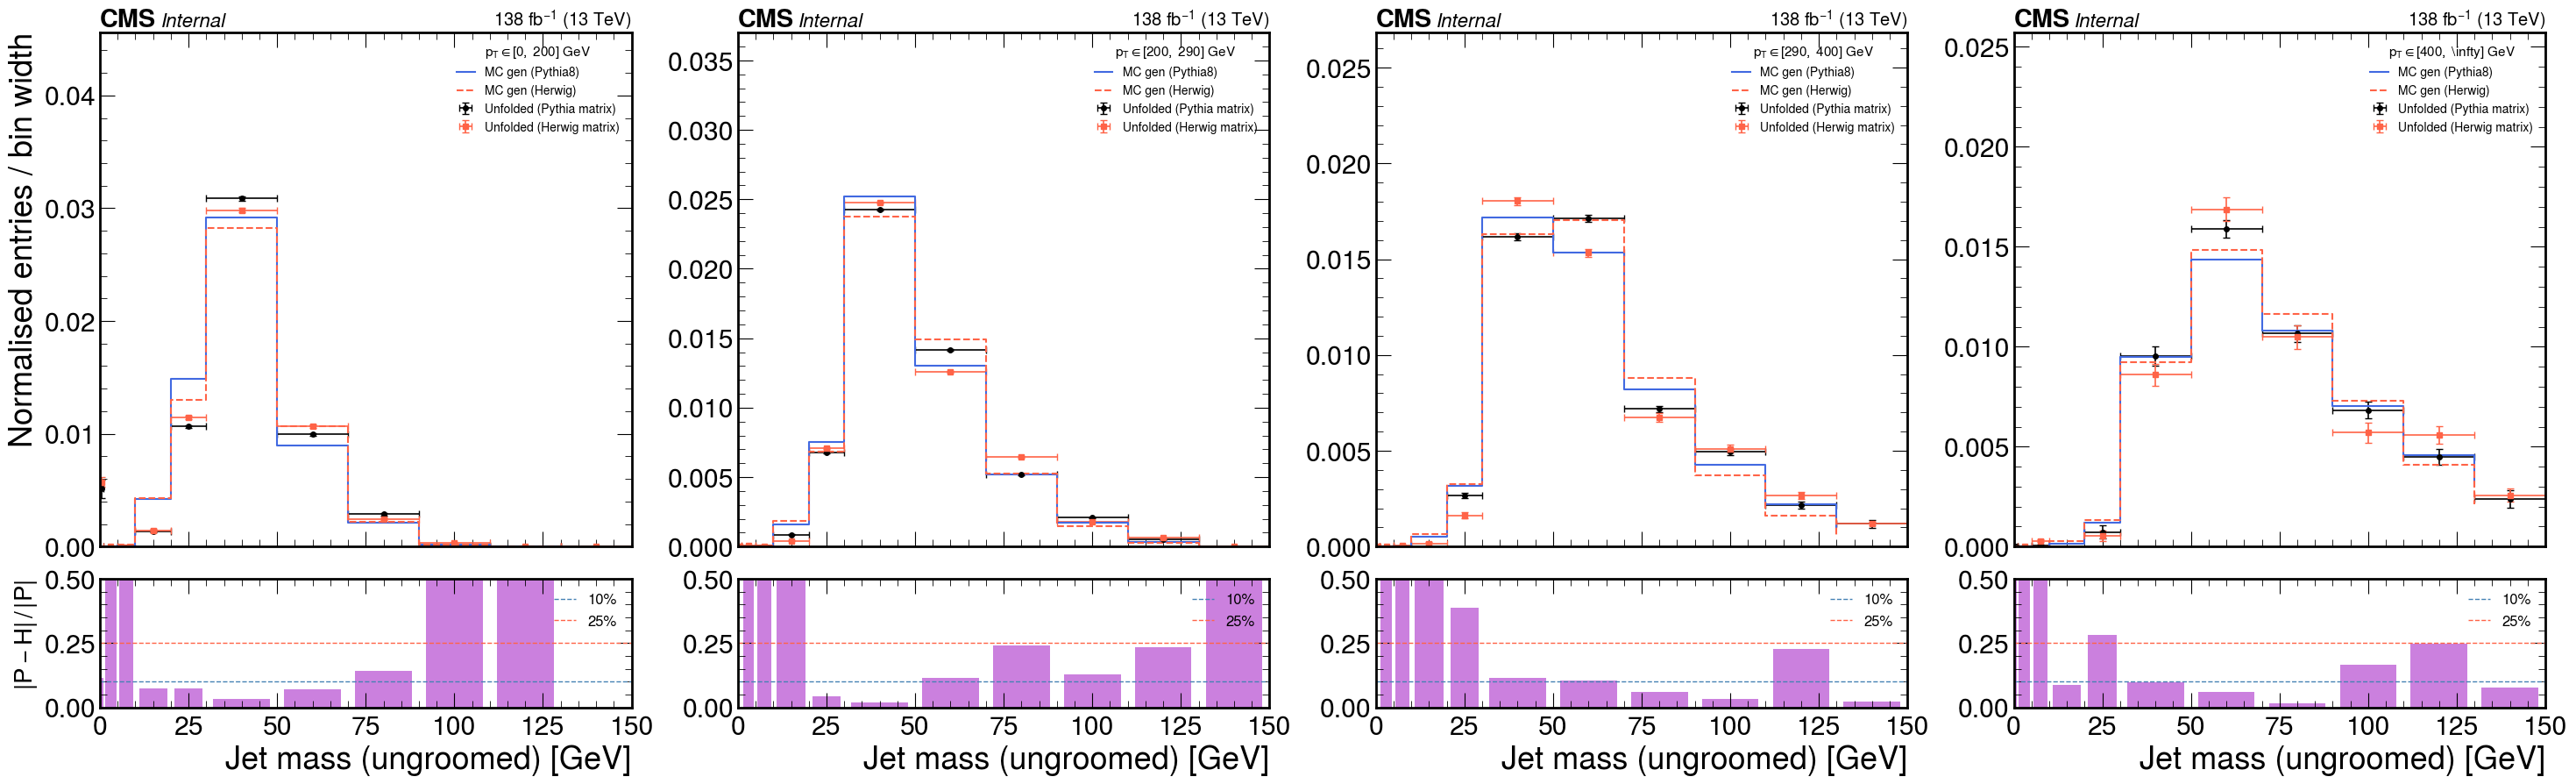

In [14]:
pt_edges = ptgen_edges
m_edges  = np.array(CUSTOM_REBIN_EDGES) if CUSTOM_REBIN_EDGES is not None else mgen_edges
m_centres = 0.5 * (m_edges[:-1] + m_edges[1:])
m_widths  = m_edges[1:] - m_edges[:-1]

obs_label = r'Jet mass (groomed) [GeV]' if OBS == 'g' else r'Jet mass (ungroomed) [GeV]'

# ── Layout: 1 row when USE_TWO_MC is off, 2 rows (main + rel.unc.) when on ──
if USE_TWO_MC:
    fig, axes_all = plt.subplots(
        2, n_ptgen,
        figsize=(9 * n_ptgen, 10),
        gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.1},
        sharex='col'
    )
    if n_ptgen == 1:
        axes_all = axes_all.reshape(2, 1)
    axes_main  = axes_all[0]
    axes_ratio = axes_all[1]
else:
    fig, axes_main = plt.subplots(1, n_ptgen, figsize=(9 * n_ptgen, 10), sharey=False)
    if n_ptgen == 1:
        axes_main = [axes_main]
    axes_ratio = None

for ipt, ax in enumerate(axes_main):
    vals_r, errs_r, edges_r = rebin_1d(
        unfolded_2d[ipt], errs_2d[ipt], mgen_edges, N_REBIN, CUSTOM_REBIN_EDGES
    )
    widths_r  = edges_r[1:] - edges_r[:-1]
    centres_r = 0.5 * (edges_r[:-1] + edges_r[1:])

    norm = (vals_r * widths_r).sum()
    if norm > 0:
        vals_r  = vals_r  / norm
        errs_r  = errs_r  / norm

    ax.errorbar(centres_r, vals_r, yerr=errs_r, xerr=widths_r / 2,
                fmt='o', ms=4, lw=1.2, capsize=3,
                color='black', label='Unfolded (Pythia matrix)')

    # ── Alt (Herwig matrix) unfolded result ───────────────────────────────────
    if USE_TWO_MC:
        v_alt, e_alt, _ = rebin_1d(
            unfolded_2d_alt[ipt], errs_2d_alt[ipt], mgen_edges, N_REBIN, CUSTOM_REBIN_EDGES
        )
        norm_alt = (v_alt * widths_r).sum()
        if norm_alt > 0:
            v_alt /= norm_alt
            e_alt /= norm_alt
        ax.errorbar(centres_r, v_alt, yerr=e_alt, xerr=widths_r / 2,
                    fmt='s', ms=4, lw=1.2, capsize=3,
                    color='tomato', label='Unfolded (Herwig matrix)')

    # MC gen — rebin to match displayed axis
    mc_g = mc_gen_flat.reshape(n_ptgen, n_mgen)[ipt]
    mc_r, _, _ = rebin_1d(mc_g, np.sqrt(mc_g), mgen_edges, N_REBIN, CUSTOM_REBIN_EDGES)
    norm_mc = (mc_r * widths_r).sum()
    if norm_mc > 0:
        mc_r = mc_r / norm_mc
    ax.step(edges_r[:-1], mc_r, where='post', lw=1.5,
            color='royalblue', label='MC gen (Pythia8)')

    if USE_TWO_MC:
        mc_g_alt = mc_gen_flat_alt.reshape(n_ptgen, n_mgen)[ipt]
        mc_r_alt, _, _ = rebin_1d(mc_g_alt, np.sqrt(mc_g_alt), mgen_edges, N_REBIN, CUSTOM_REBIN_EDGES)
        norm_mc_alt = (mc_r_alt * widths_r).sum()
        if norm_mc_alt > 0:
            mc_r_alt = mc_r_alt / norm_mc_alt
        ax.step(edges_r[:-1], mc_r_alt, where='post', lw=1.5,
                color='tomato', ls='--', label='MC gen (Herwig)')

    # Headroom so CMS label doesn't overlap data
    ax.set_ylim(bottom=0)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.4)

    pt_lo = int(pt_edges[ipt])
    pt_hi = int(pt_edges[ipt + 1]) if ipt < n_ptgen - 1 else r'$\infty$'
    if ipt == 0:
        ax.set_ylabel('Normalised entries / bin width')
    ax.legend(fontsize=10, loc='upper right',
              title=f'$p_{{T}} \\in [{pt_lo},\ {pt_hi}]$ GeV',
              title_fontsize=11)
    ax.set_xlim(edges_r[0], edges_r[-1])
    if axes_ratio is None:
        ax.set_xlabel(obs_label)

    # ── Relative uncertainty panel ────────────────────────────────────────────
    if USE_TWO_MC:
        ax_r = axes_ratio[ipt]
        with np.errstate(divide='ignore', invalid='ignore'):
            rel_unc = np.where(np.abs(vals_r) > 0,
                               np.abs(vals_r - v_alt) / np.abs(vals_r),
                               0.0)
        ax_r.bar(centres_r, rel_unc, width=widths_r * 0.8,
                 color='mediumorchid', alpha=0.75)
        ax_r.axhline(0,    color='k',         lw=0.7)
        ax_r.axhline(0.10, color='steelblue', lw=1.0, ls='--', label='10%')
        ax_r.axhline(0.25, color='tomato',    lw=1.0, ls='--', label='25%')
        ax_r.set_xlabel(obs_label)
        if ipt == 0:
            ax_r.set_ylabel(r'$|P - H|\,/\,|P|$', fontsize=20)
        ax_r.set_xlim(edges_r[0], edges_r[-1])
        ax_r.set_ylim(0, 0.5)
        ax_r.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
        ax_r.legend(fontsize=12, loc='upper right')


plt.tight_layout()
for ax in axes_main:
    hep.cms.label("Internal", lumi=138, com=13, fontsize=16, data = True, ax=ax)
plt.show()


### 7d  Closure test  (MC reco → unfold → compare with MC gen)

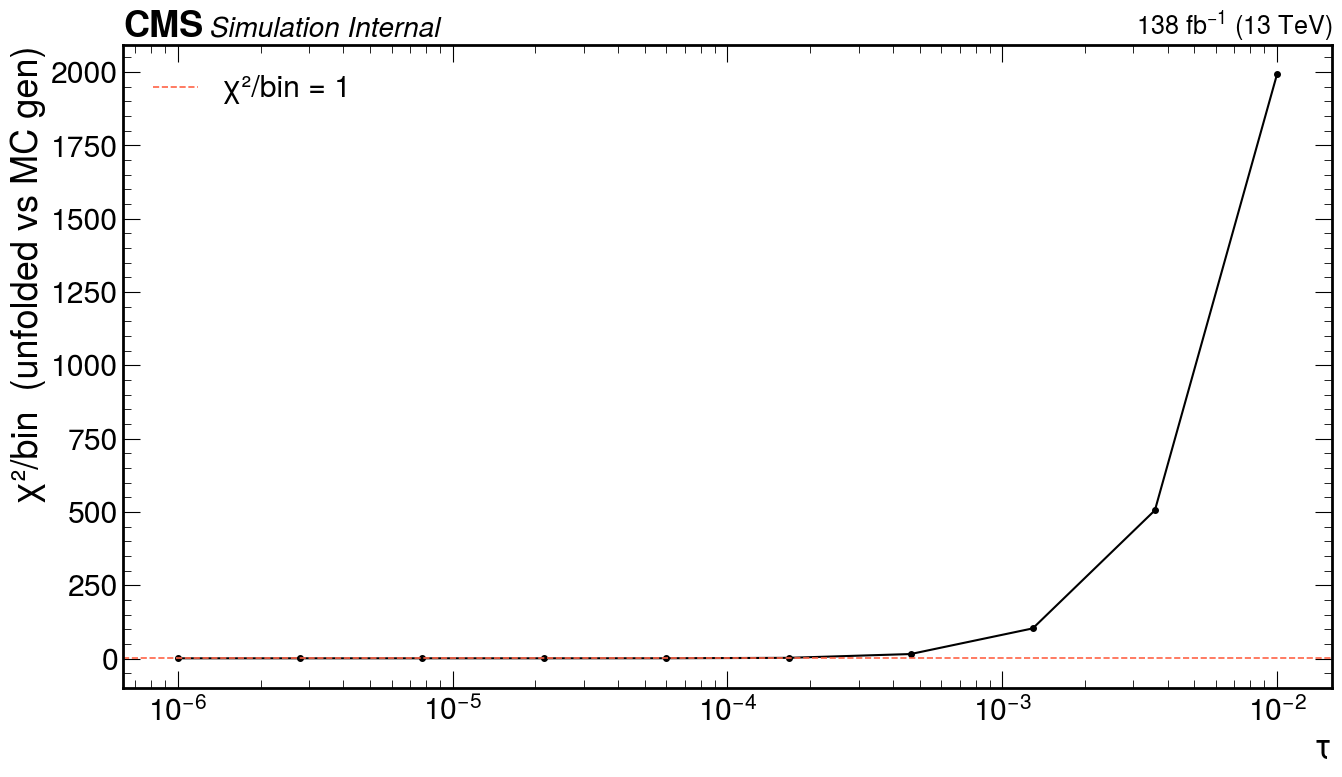

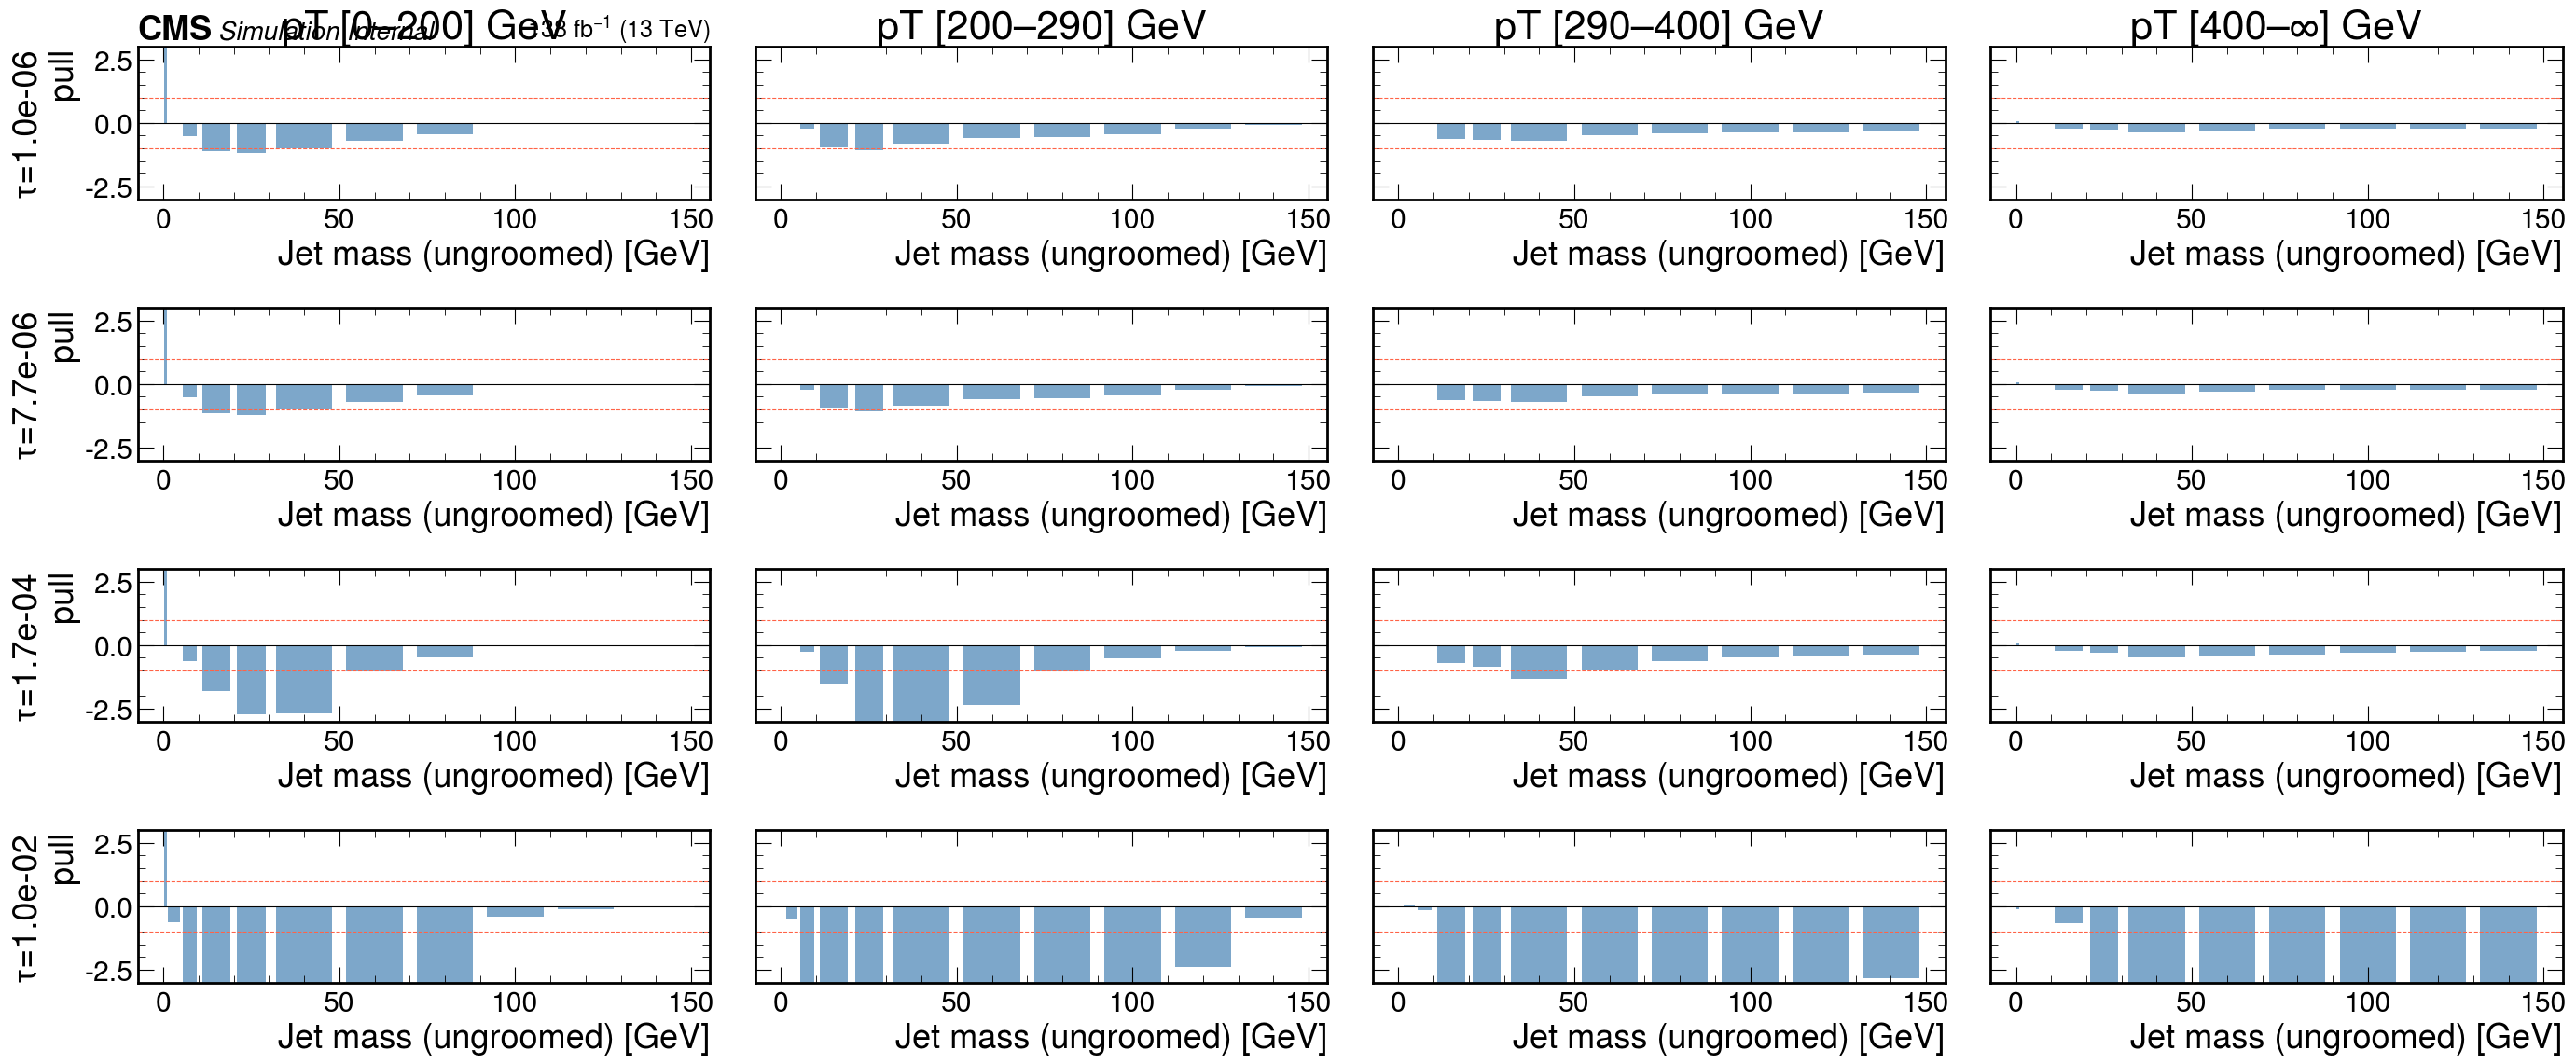

Last τ with χ²/bin < 2.0: 5.99e-05


Info in <TUnfold::SetConstraint>: fConstraint=1
Warning in <TUnfold::TUnfold>: 71 output bins do not depend on the input data  0 2-5 66 68-108 198-216 320-323 426
Info in <TUnfold::TUnfold>: 852 input bins and 356 output bins
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #0 (xaxis:gen global bin[ufl])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #2 (xaxis:gen global bin[0.5,1.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #3 (xaxis:gen global bin[1.5,2.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #4 (xaxis:gen global bin[2.5,3.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #5 (xaxis:gen global bin[3.5,4.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #66 (xaxis:gen global bin[64.5,65.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #68 (xaxis:gen global bin[66.5,67.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #69 (xaxis:gen global bin[67.5,68.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfoldin

In [ ]:
# # ── τ scan closure test ──────────────────────────────────────────────────────
# tau_values = np.logspace(-6, -2, 10)   # adjust range based on your scale

# chi2_per_tau   = []
# pulls_per_tau  = []

# for tau in tau_values:
#     # Run closure: unfold MC reco with MC response
#     tu_cl = ROOT.TUnfoldDensity(
#         h_response,
#         ROOT.TUnfold.kHistMapOutputHoriz,
#         ROOT.TUnfold.kRegModeDerivative,
#         ROOT.TUnfold.kEConstraintArea,
#         ROOT.TUnfoldDensity.kDensityModeBinWidth
#     )
#     tu_cl.SetInput(h_mc_reco)
#     tu_cl.DoUnfold(tau)

#     h_cl = tu_cl.GetOutput(f'h_closure_tau')
#     cl_vals, cl_errs = th1_to_numpy(h_cl)
#     cl_vals = cl_vals[:n_gen_global]
#     cl_errs = cl_errs[:n_gen_global]

#     cl_vals_2d = cl_vals.reshape(n_ptgen, n_mgen)
#     cl_errs_2d = cl_errs.reshape(n_ptgen, n_mgen)
#     cl_vals_rb = []
#     cl_errs_rb = []
#     gen_rb = []
#     for ipt in range(n_ptgen):
#         vals_r, errs_r, _ = rebin_1d(
#             cl_vals_2d[ipt], cl_errs_2d[ipt], mgen_edges, N_REBIN, CUSTOM_REBIN_EDGES
#         )
#         gen_r, _, _ = rebin_1d(
#             mc_gen_flat.reshape(n_ptgen, n_mgen)[ipt],
#             np.sqrt(np.maximum(mc_gen_flat.reshape(n_ptgen, n_mgen)[ipt], 0.0)),
#             mgen_edges, N_REBIN, CUSTOM_REBIN_EDGES
#         )
#         cl_vals_rb.append(vals_r)
#         cl_errs_rb.append(errs_r)
#         gen_rb.append(gen_r)

#     cl_vals_rb = np.concatenate(cl_vals_rb)
#     cl_errs_rb = np.concatenate(cl_errs_rb)
#     gen_rb = np.concatenate(gen_rb)

#     # Compare to MC gen truth on the displayed rebinned axis
#     with np.errstate(divide='ignore', invalid='ignore'):
#         pulls = np.where(cl_errs_rb > 0,
#                          (cl_vals_rb - gen_rb) / cl_errs_rb,
#                          0.0)

#     # χ² per rebinned bin between unfolded and gen truth
#     chi2 = np.sum(pulls**2) / len(gen_rb)

#     chi2_per_tau.append(chi2)
#     pulls_per_tau.append(pulls)

# chi2_per_tau = np.array(chi2_per_tau)

# # ── Plot χ² vs τ ─────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(14, 8))
# ax.semilogx(tau_values, chi2_per_tau, 'o-', ms=4, color='black')
# ax.axhline(1.0, color='tomato', ls='--', lw=1.2, label='χ²/bin = 1')
# ax.set_xlabel('τ')
# ax.set_ylabel('χ²/bin  (unfolded vs MC gen)')
# ax.legend()
# plt.tight_layout()
# hep.cms.label("Internal", lumi=138, com=13, fontsize=20, ax=ax)
# plt.show()

# # ── Plot pulls per pT bin for a few representative τ values ─────────────────
# tau_indices = [0, len(tau_values)//4, len(tau_values)//2, -1]   # few points across scan

# fig, axes = plt.subplots(len(tau_indices), n_ptgen,
#                          figsize=(7 * n_ptgen, 3 * len(tau_indices)),
#                          sharey='row')
# if len(tau_indices) == 1 and n_ptgen == 1:
#     axes = np.array([[axes]])
# elif len(tau_indices) == 1:
#     axes = axes.reshape(1, n_ptgen)
# elif n_ptgen == 1:
#     axes = axes.reshape(len(tau_indices), 1)

# n_display_bins = len(rebin_1d(
#     mc_gen_flat.reshape(n_ptgen, n_mgen)[0],
#     np.sqrt(np.maximum(mc_gen_flat.reshape(n_ptgen, n_mgen)[0], 0.0)),
#     mgen_edges, N_REBIN, CUSTOM_REBIN_EDGES
#  )[0])

# for row, itau in enumerate(tau_indices):
#     pulls_2d = pulls_per_tau[itau].reshape(n_ptgen, n_display_bins)
#     for ipt in range(n_ptgen):
#         ax = axes[row, ipt]
#         _, _, edges_r = rebin_1d(
#             mc_gen_flat.reshape(n_ptgen, n_mgen)[ipt],
#             np.sqrt(np.maximum(mc_gen_flat.reshape(n_ptgen, n_mgen)[ipt], 0.0)),
#             mgen_edges, N_REBIN, CUSTOM_REBIN_EDGES
#         )
#         centres_r = 0.5 * (edges_r[:-1] + edges_r[1:])
#         widths_r  = edges_r[1:] - edges_r[:-1]

#         ax.bar(centres_r, pulls_2d[ipt], width=widths_r * 0.8,
#                color='steelblue', alpha=0.7)
#         ax.axhline(0,    color='k',      lw=0.8)
#         ax.axhline(+1,   color='tomato', lw=0.8, ls='--')
#         ax.axhline(-1,   color='tomato', lw=0.8, ls='--')
#         ax.set_ylim(-3, 3)

#         if row == 0:
#             pt_lo = int(ptgen_edges[ipt])
#             pt_hi = int(ptgen_edges[ipt+1]) if ipt < n_ptgen-1 else '∞'
#             ax.set_title(f'pT [{pt_lo}–{pt_hi}] GeV')
#         if ipt == 0:
#             ax.set_ylabel(f'τ={tau_values[itau]:.1e}\npull')
#         ax.set_xlabel(obs_label)

# plt.tight_layout()
# hep.cms.label("Internal", lumi=138, com=13, fontsize=20, ax=axes[0, 0])
# plt.show()

# # ── Print the last τ before χ²/bin exceeds threshold ────────────────────────
# threshold = 2.0
# valid_taus = tau_values[chi2_per_tau < threshold]
# if len(valid_taus) > 0:
#     print(f'Last τ with χ²/bin < {threshold}: {valid_taus[-1]:.2e}')
# else:
#     print(f'All τ values exceed χ²/bin threshold of {threshold}')

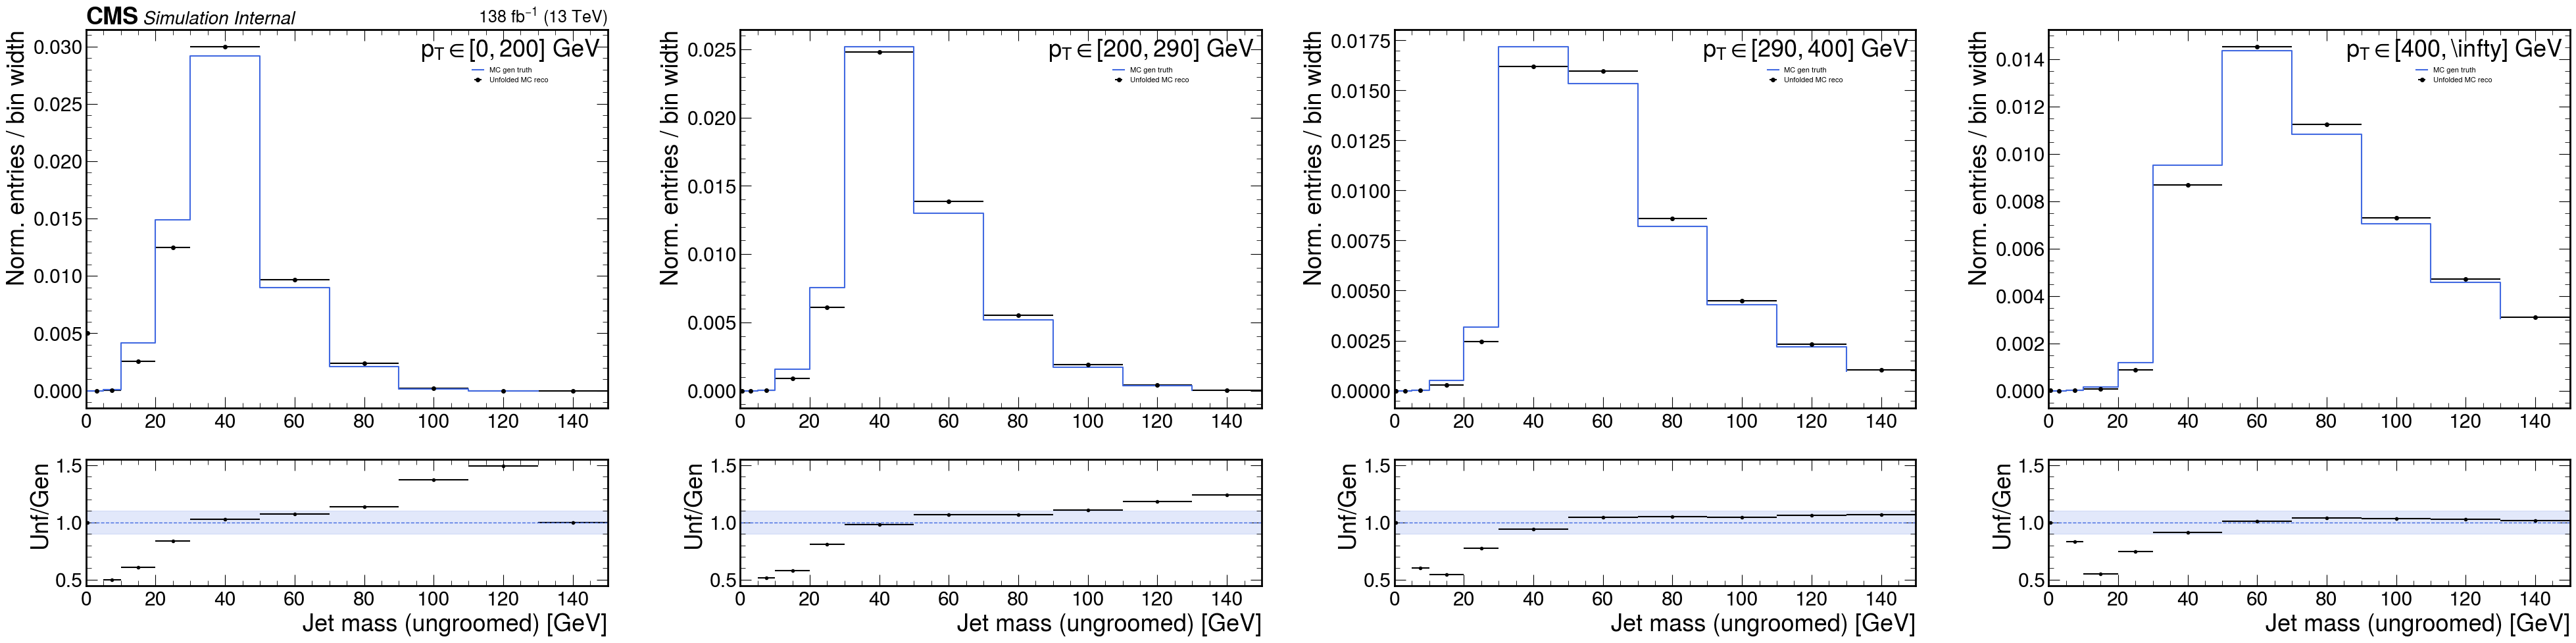

Info in <TUnfold::SetConstraint>: fConstraint=1
Warning in <TUnfold::TUnfold>: 71 output bins do not depend on the input data  0 2-5 66 68-108 198-216 320-323 426
Info in <TUnfold::TUnfold>: 852 input bins and 356 output bins
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #0 (xaxis:gen global bin[ufl])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #2 (xaxis:gen global bin[0.5,1.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #3 (xaxis:gen global bin[1.5,2.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #4 (xaxis:gen global bin[2.5,3.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #5 (xaxis:gen global bin[3.5,4.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #66 (xaxis:gen global bin[64.5,65.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #68 (xaxis:gen global bin[66.5,67.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #69 (xaxis:gen global bin[67.5,68.5])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfoldin

In [16]:
# Run a separate TUnfold instance with MC reco as input
tunfold_closure = ROOT.TUnfoldDensity(
    h_response,
    ROOT.TUnfold.kHistMapOutputHoriz,
    ROOT.TUnfold.kRegModeNone,
    ROOT.TUnfold.kEConstraintArea,
    ROOT.TUnfoldDensity.kDensityModeNone
)
tunfold_closure.SetInput(h_mc_reco)
tunfold_closure.DoUnfold(TAU)

h_closure = tunfold_closure.GetOutput(f'h_closure_{OBS}')
closure_vals, closure_errs = th1_to_numpy(h_closure)
closure_vals = closure_vals[:n_gen_global]
closure_errs = closure_errs[:n_gen_global]
closure_2d = closure_vals.reshape(n_ptgen, n_mgen)
closure_errs_2d = closure_errs.reshape(n_ptgen, n_mgen)

fig, axes = plt.subplots(2, n_ptgen, figsize=(10 * n_ptgen, 10),
                         gridspec_kw={'height_ratios': [3, 1]})
if n_ptgen == 1:
    axes = axes.reshape(2, 1)

for ipt in range(n_ptgen):
    ax_main  = axes[0, ipt]
    ax_ratio = axes[1, ipt]

    clo = closure_2d[ipt]
    clo_e = closure_errs_2d[ipt]
    gen = mc_gen_flat.reshape(n_ptgen, n_mgen)[ipt]

    clo_r, clo_e_r, edges_r = rebin_1d(clo, clo_e, mgen_edges, N_REBIN, CUSTOM_REBIN_EDGES)
    gen_r, _, _ = rebin_1d(
        gen, np.sqrt(np.maximum(gen, 0.0)), mgen_edges, N_REBIN, CUSTOM_REBIN_EDGES
    )
    centres_r = 0.5 * (edges_r[:-1] + edges_r[1:])
    widths_r = edges_r[1:] - edges_r[:-1]

    norm_clo = (clo_r * widths_r).sum()
    norm_gen = (gen_r * widths_r).sum()
    clo_n = clo_r / norm_clo if norm_clo > 0 else clo_r
    clo_e_n = clo_e_r / norm_clo if norm_clo > 0 else clo_e_r
    gen_n = gen_r / norm_gen if norm_gen > 0 else gen_r

    ax_main.errorbar(centres_r, clo_n, 
                    #yerr=clo_e_n, 
                    xerr=widths_r / 2,
                     fmt='o', ms=4, color='black', label='Unfolded MC reco')
    ax_main.step(edges_r[:-1], gen_n, where='post', lw=1.5,
                 color='royalblue', label='MC gen truth')

    pt_lo = int(pt_edges[ipt])
    pt_hi = int(pt_edges[ipt + 1]) if ipt < n_ptgen - 1 else r'$\infty$'
    #ax_main.set_title(f'$p_T \\in [{pt_lo},{pt_hi}]$ GeV')
    ax_main.set_ylabel('Norm. entries / bin width')
    ax_main.legend(fontsize=8, title = f'$p_T \\in [{pt_lo},{pt_hi}]$ GeV')
    ax_main.set_xlim(edges_r[0], edges_r[-1])

    # Ratio panel on the same rebinned mass axis
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(gen_n > 0, clo_n / gen_n, 1.0)
        ratio_e = np.where(gen_n > 0, clo_e_n / gen_n, 0.0)
    ax_ratio.errorbar(centres_r, ratio, 
                        #yerr=ratio_e, 
                        xerr=widths_r / 2,
                      fmt='o', ms=3, color='black')
    ax_ratio.axhline(1.0, color='royalblue', lw=1.0, ls='--')
    ax_ratio.axhspan(0.9, 1.1, alpha=0.15, color='royalblue')
    ax_ratio.set_ylim(0.45, 1.55)
    ax_ratio.set_xlabel(obs_label)
    ax_ratio.set_ylabel('Unf/Gen')
    ax_ratio.set_xlim(edges_r[0], edges_r[-1])

plt.tight_layout()
hep.cms.label("Internal", lumi=138, com=13, fontsize=20, ax=axes[0, 0])
plt.show()

### 7e  Efficiency and fake rate per pT bin

<>:21: SyntaxWarning: invalid escape sequence '\i'
<>:21: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_9364/2453153487.py:21: SyntaxWarning: invalid escape sequence '\i'
  ax.set_title(f'$p_T \in [{pt_lo},{pt_hi}]$ GeV')
/tmp/ipykernel_9364/2453153487.py:3: RuntimeWarning: invalid value encountered in divide
  fakes_flat / mc_reco_flat, 0.0)


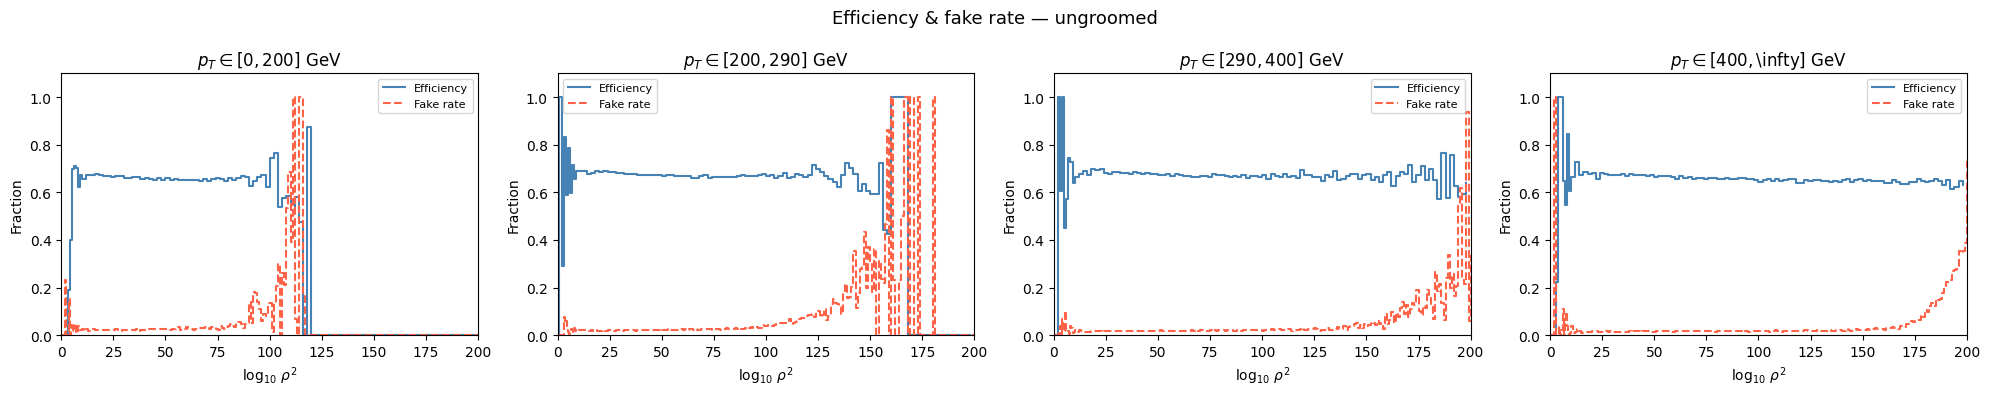

In [77]:
eff_2d       = efficiency_flat.reshape(n_ptgen, n_mgen)
fakerate_flat = np.where(mc_reco_flat > 0,
                         fakes_flat / mc_reco_flat, 0.0)
fakerate_2d  = fakerate_flat.reshape(n_ptreco, n_mreco)

fig, axes = plt.subplots(1, n_ptgen, figsize=(5 * n_ptgen, 4))
if n_ptgen == 1:
    axes = [axes]

for ipt, ax in enumerate(axes):
    ax.step(m_edges[:-1], eff_2d[ipt],       where='post', lw=1.5,
            color='steelblue', label='Efficiency')
    # Fake rate uses reco mass binning
    m_reco_edges   = mreco_edges
    m_reco_centres = 0.5 * (m_reco_edges[:-1] + m_reco_edges[1:])
    ax.step(m_reco_edges[:-1], fakerate_2d[ipt], where='post', lw=1.5,
            color='tomato', ls='--', label='Fake rate')

    pt_lo = int(pt_edges[ipt])
    pt_hi = int(pt_edges[ipt + 1]) if ipt < n_ptgen - 1 else r'$\infty$'
    ax.set_title(f'$p_T \in [{pt_lo},{pt_hi}]$ GeV')
    ax.set_xlabel(obs_label)
    ax.set_ylabel('Fraction')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_xlim(m_edges[0], m_edges[-1])

plt.tight_layout()
hep.cms.label("Internal", lumi=138, com=13, fontsize=20, ax=axes[0])
plt.show()

### 7f  Total covariance matrix

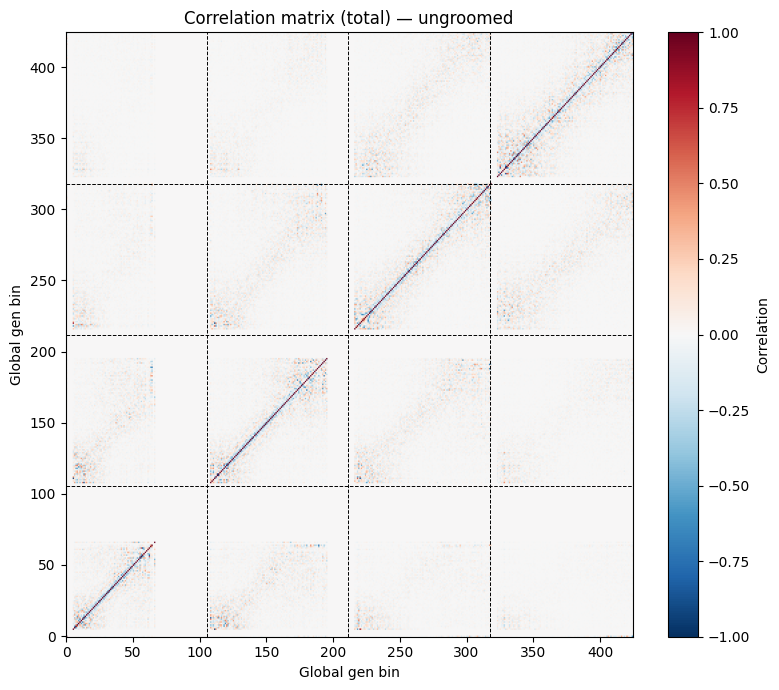

In [78]:
# Compute the correlation matrix from the covariance
std = np.sqrt(np.diag(cov_matrix))
outer = np.outer(std, std)
with np.errstate(divide='ignore', invalid='ignore'):
    corr_matrix = np.where(outer > 0, cov_matrix / outer, 0.0)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix, origin='lower', aspect='auto',
               vmin=-1, vmax=1, cmap='RdBu_r')
plt.colorbar(im, ax=ax, label='Correlation')

# pT block boundaries
for k in range(1, n_ptgen):
    ax.axvline(k * n_mgen - 0.5, color='k', lw=0.7, ls='--')
    ax.axhline(k * n_mgen - 0.5, color='k', lw=0.7, ls='--')

ax.set_xlabel('Global gen bin')
ax.set_ylabel('Global gen bin')
plt.tight_layout()
hep.cms.label("Internal", lumi=138, com=13, fontsize=20, ax=ax)
plt.show()

## 8  — Quick summary printout

In [79]:
print('=' * 60)
print(f'Unfolding summary  [{"ungroomed" if OBS=="u" else "groomed"} jet mass]')
print('=' * 60)
print(f'  TUnfold status       : {status}')
print(f'  Regularisation τ     : {TAU}')
print(f'  Global reco bins     : {n_reco_global}')
print(f'  Global gen  bins     : {n_gen_global}')
print(f'  Mean efficiency      : {efficiency_flat[efficiency_flat>0].mean():.3f}')
print(f'  Bins below P/S = 0.5 : {n_below}')
print('\nUnfolded integrals per pT bin:')
for ipt in range(n_ptgen):
    pt_lo = int(pt_edges[ipt])
    pt_hi = int(pt_edges[ipt + 1]) if ipt < n_ptgen - 1 else 'inf'
    integral = unfolded_2d[ipt].sum()
    print(f'  pT [{pt_lo:>5} – {str(pt_hi):>5}] GeV :  {integral:.1f} events')
print('=' * 60)

Unfolding summary  [ungroomed jet mass]
  TUnfold status       : 0.9996387231157197
  Regularisation τ     : 0.0
  Global reco bins     : 852
  Global gen  bins     : 424
  Mean efficiency      : 0.667
  Bins below P/S = 0.5 : 424

Unfolded integrals per pT bin:
  pT [    0 –   200] GeV :  79954.0 events
  pT [  200 –   290] GeV :  176175.7 events
  pT [  290 –   400] GeV :  49157.3 events
  pT [  400 –   inf] GeV :  19193.6 events
